In [15]:
import os
import numpy as np
from PIL import Image

### Image Preprocessing

1. Grayscale
2. Thresholding
3. Cropping/Bounding Box

In [2]:
def rgb2gray(rgb):
    return np.dot(rgb[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

In [3]:
chulpi_input_path = 'dataset/Gaussian Naive Bayes/color/Zea_mays_Chulpi_Cancha/'
chulpi_output_path = 'dataset/Gaussian Naive Bayes/color_gray/Zea_mays_Chulpi_Cancha/'

indurata_input_path = 'dataset/Gaussian Naive Bayes/color/Zea_mays_Indurata/'
indurata_output_path = 'dataset/Gaussian Naive Bayes/color_gray/Zea_mays_Indurata/'

rugosa_input_path = 'dataset/Gaussian Naive Bayes/color/Zea_mays_Rugosa/'
rugosa_output_path = 'dataset/Gaussian Naive Bayes/color_gray/Zea_mays_Rugosa/'

### Make output file

In [4]:
def mkdir(output_path):
    if not os.path.exists(output_path):
        os.makedirs(output_path)

In [5]:
mkdir(chulpi_output_path)
mkdir(indurata_output_path)
mkdir(rugosa_output_path)

### Import IMG Dataset

In [6]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp")

In [7]:
def gen_gray(input_path, output_path):
    image_files = [f for f in os.listdir(input_path) if f.lower().endswith(valid_extensions)]
    image_files = sorted(
        image_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )
    print(f"The total img: {len(image_files)}")

    image_files = input_path + np.asarray(image_files)
    color_img = [Image.open(str(i)).convert('RGB') for i in image_files]
    img_array = np.asarray(color_img)

    print(f'The img shape: {img_array.shape}')

    # Parse color img into gray color
    for idx, img in enumerate(img_array):
        img_height_size = len(img)
        img_width_size = len(img[0])
        gray_array = np.zeros((img_height_size, img_width_size), dtype=np.uint8)
        for i in range(img_height_size):
            for j in range(img_width_size):
                gray_array[i, j] = int(rgb2gray(img[i, j]))
        img_gray = Image.fromarray(gray_array)
        img_gray.save(f'{output_path}{idx + 1}.jpg')


In [ ]:
gen_gray(chulpi_input_path, chulpi_output_path)
gen_gray(indurata_input_path, indurata_output_path)
gen_gray(rugosa_input_path, rugosa_output_path)

### Binary Thresholding

Binary thresholding converts a grayscale image into a binary image
containing only black (0) and white (255).

For each pixel:

$$
g(i,j) =
\begin{cases}
255 & \text{if } I(i,j) \geq T \\
0 & \text{if } I(i,j) < T
\end{cases}
$$

**Where:**

- $I(i,j)$ → original pixel intensity
- $T$ → threshold
- $g(i,j)$ → output pixel
- $255$ → white
- $0$ → black

This allows bright objects, such as corn kernels, to be separated
from the darker background.

In [9]:
THREADHOLD_VALUE = 30

In [10]:
chulpi_input_path = 'dataset/Gaussian Naive Bayes/color_gray/Zea_mays_Chulpi_Cancha/'
chulpi_output_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulpi_Cancha/'

indurata_input_path = 'dataset/Gaussian Naive Bayes/color_gray/Zea_mays_Indurata/'
indurata_output_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Indurata/'

rugosa_input_path = 'dataset/Gaussian Naive Bayes/color_gray/Zea_mays_Rugosa/'
rugosa_output_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Rugosa/'

In [11]:
def gen_binary(input_path, output_path):
    image_files = [f for f in os.listdir(input_path) if f.lower().endswith(valid_extensions)]
    image_files = sorted(
        image_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )
    print(f"The total img: {len(image_files)}")

    image_files = input_path + np.asarray(image_files)
    gray_img = [Image.open(str(i)).convert('L') for i in image_files]
    img_array = np.asarray(gray_img)

    print(f'The img shape: {img_array.shape}')

    # Parse color img into gray color
    for idx, img in enumerate(img_array):
        img_height_size = len(img)
        img_width_size = len(img[0])
        binary_array = np.zeros((img_height_size, img_width_size), dtype=np.uint8)
        for i in range(img_height_size):
            for j in range(img_width_size):
                binary_array[i, j] = 255 if (img[i, j] >= THREADHOLD_VALUE) else 0
        img_binary = Image.fromarray(binary_array)
        img_binary.save(f'{output_path}{idx+1}.jpg')

In [12]:
mkdir(chulpi_output_path)
mkdir(indurata_output_path)
mkdir(rugosa_output_path)

In [ ]:
gen_binary(chulpi_input_path, chulpi_output_path)
gen_binary(indurata_input_path, indurata_output_path)
gen_binary(rugosa_input_path, rugosa_output_path)

## Cropping / Bounding Box

### 1. Mathematical Concept

After obtaining a binary image, the next step is to determine the location of the object, such as a corn kernel, in order to limit the region used for further processing.

The computer scans the binary image matrix and finds the four boundaries of the white object (pixel value = 255):

- **Top**: the smallest row index $i$ where a white pixel appears.
- **Bottom**: the largest row index $i$ where a white pixel appears.
- **Left**: the smallest column index $j$ where a white pixel appears.
- **Right**: the largest column index $j$ where a white pixel appears.

These four coordinates define the **Bounding Box** of the object.

Mathematically:

$$
\begin{aligned}
Top &= \min\{i \mid I(i,j)=255\} \\
Bottom &= \max\{i \mid I(i,j)=255\} \\
Left &= \min\{j \mid I(i,j)=255\} \\
Right &= \max\{j \mid I(i,j)=255\}
\end{aligned}
$$

Once the four boundaries are determined, **matrix slicing** can be used to extract the region between them:

$$
I_{crop} = I[Top:Bottom+1,\; Left:Right+1]
$$

The result is a smaller image containing only the region occupied by the corn kernel, which reduces the area that needs to be processed in subsequent steps.

In [ ]:
def gen_cropped(input_path, output_path):
    image_files = [f for f in os.listdir(input_path) if f.lower().endswith(valid_extensions)]
    image_files = sorted(
        image_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )
    print(f"The total img: {len(image_files)}")

    image_files = input_path + np.asarray(image_files)
    binary_img = [Image.open(str(i)) for i in image_files]
    img_array = np.asarray(binary_img)

    print(f'The img shape: {img_array.shape}')

    # Parse color img into gray color
    for idx, img in enumerate(img_array):
        img_height_size = len(img)
        img_width_size = len(img[0])
        top = img_height_size
        bottom = 0
        left = img_width_size
        right = 0
        for i in range(img_height_size):
            for j in range(img_width_size):
                if img[i, j] != 0:
                    if i < top: top = i
                    if i > bottom: bottom = i
                    if j < left: left = j
                    if j > right: right = j
        cropped_array = img[top:bottom+1, left:right+1]
        img_cropped = Image.fromarray(cropped_array)
        img_cropped.save(f'{output_path}{idx+1}.jpg')

In [ ]:
chulpi_input_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulpi_Cancha/'
chulpi_output_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Chulpi_Cancha/'

indurata_input_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Indurata/'
indurata_output_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Indurata/'

rugosa_input_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Rugosa/'
rugosa_output_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Rugosa/'

In [ ]:
mkdir(chulpi_output_path)
mkdir(indurata_output_path)
mkdir(rugosa_output_path)

In [ ]:
gen_cropped(chulpi_input_path, chulpi_output_path)
gen_cropped(indurata_input_path, indurata_output_path)
gen_cropped(rugosa_input_path, rugosa_output_path)

The total img: 350
The img shape: (350, 400, 400)
The total img: 350
The img shape: (350, 400, 400)
The total img: 350
The img shape: (350, 400, 400)


In [ ]:
def gen_synchronized_cropped(binary_dir, color_dir, output_color_dir):

    os.makedirs(output_color_dir, exist_ok=True)

    # =========================
    # Create color image mapping
    # =========================
    color_img_files = [
        f for f in os.listdir(color_dir)
        if f.lower().endswith(valid_extensions)
    ]

    color_img_files = sorted(
        color_img_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )

    print(f"The total color img: {len(color_img_files)}")

    # filename -> full path
    color_mapping = {
        f: os.path.join(color_dir, f)
        for f in color_img_files
    }

    # =========================
    # Binary images
    # =========================
    binary_img_files = [
        f for f in os.listdir(binary_dir)
        if f.lower().endswith(valid_extensions)
    ]

    binary_img_files = sorted(
        binary_img_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )

    print(f"The total binary images to process: {len(binary_img_files)}")

    # =========================
    # Process each binary image
    # =========================
    for file_name in binary_img_files:

        # Binary path
        binary_path = os.path.join(binary_dir, file_name)

        # Find corresponding color image
        if file_name not in color_mapping:
            print(f"Warning: No matching color image for {file_name}")
            continue

        color_path = color_mapping[file_name]

        print(f"Processing: {file_name}")
        print(f"    Binary: {binary_path}")
        print(f"    Color : {color_path}")

        # Read binary
        bin_img = Image.open(binary_path)
        bin_arr = np.array(bin_img)

        # Read corresponding color image
        color_img = Image.open(color_path).convert('RGB')
        color_arr = np.array(color_img)

        height, width = bin_arr.shape

        top = height
        bottom = -1
        left = width
        right = -1

        # =========================
        # Find bounding box
        # =========================
        for i in range(height):
            for j in range(width):

                if bin_arr[i, j] == 255:

                    if i < top:
                        top = i

                    if i > bottom:
                        bottom = i

                    if j < left:
                        left = j

                    if j > right:
                        right = j

        # No object detected
        if bottom < top or right < left:
            print(f"Warning: No kernel detected in {file_name}. Skipping...")
            continue

        # =========================
        # Crop color image
        # =========================
        cropped_color = color_arr[
            top:bottom + 1,
            left:right + 1,
            :
        ]

        img_color_out = Image.fromarray(cropped_color)

        # KEEP ORIGINAL FILENAME
        output_path = os.path.join(
            output_color_dir,
            file_name
        )

        img_color_out.save(output_path)

    print("Synchronized color cropping completed successfully!")

In [ ]:
chulpi_color_input_path = 'dataset/Gaussian Naive Bayes/color/Zea_mays_Chulpi_Cancha/'
chulpi_binary_input_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulpi_Cancha/'
chulpi_output_path = 'dataset/Gaussian Naive Bayes/color_cropped/Zea_mays_Chulpi_Cancha/'

indurata_color_input_path = 'dataset/Gaussian Naive Bayes/color/Zea_mays_Indurata/'
indurata_binary_input_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Indurata/'
indurata_output_path = 'dataset/Gaussian Naive Bayes/color_cropped/Zea_mays_Indurata/'

rugosa_color_input_path = 'dataset/Gaussian Naive Bayes/color/Zea_mays_Rugosa/'
rugosa_input_binary_path = 'dataset/Gaussian Naive Bayes/binary/Zea_mays_Rugosa/'
rugosa_output_path = 'dataset/Gaussian Naive Bayes/color_cropped/Zea_mays_Rugosa/'

In [ ]:
mkdir(chulpi_output_path)
mkdir(indurata_output_path)
mkdir(rugosa_output_path)

In [ ]:
gen_synchronized_cropped(chulpi_binary_input_path, chulpi_color_input_path, chulpi_output_path)
gen_synchronized_cropped(indurata_binary_input_path, indurata_color_input_path, indurata_output_path)
gen_synchronized_cropped(rugosa_input_binary_path, rugosa_color_input_path, rugosa_output_path)

The total color img: 351
The total binary images to process: 350
Processing: 1.jpg
    Binary: dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulpi_Cancha/1.jpg
    Color : dataset/Gaussian Naive Bayes/color/Zea_mays_Chulpi_Cancha/1.jpg
Processing: 2.jpg
    Binary: dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulpi_Cancha/2.jpg
    Color : dataset/Gaussian Naive Bayes/color/Zea_mays_Chulpi_Cancha/2.jpg
Processing: 3.jpg
    Binary: dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulpi_Cancha/3.jpg
    Color : dataset/Gaussian Naive Bayes/color/Zea_mays_Chulpi_Cancha/3.jpg
Processing: 4.jpg
    Binary: dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulpi_Cancha/4.jpg
    Color : dataset/Gaussian Naive Bayes/color/Zea_mays_Chulpi_Cancha/4.jpg
Processing: 5.jpg
    Binary: dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulpi_Cancha/5.jpg
    Color : dataset/Gaussian Naive Bayes/color/Zea_mays_Chulpi_Cancha/5.jpg
Processing: 6.jpg
    Binary: dataset/Gaussian Naive Bayes/binary/Zea_mays_Chulp

## Feature Extraction Pipeline

After cropping the binary image, we obtain two corresponding images:

- `cropped_binary`: a binary image where the object is represented by $255$ and the background by $0$.
- `cropped_color`: the original RGB image corresponding to the cropped region.

Using these two images, we extract a set of numerical features that describe the **shape, geometry, and color** of each corn kernel.

Each corn kernel is represented by a **feature vector** containing the following features:

| # | Feature | Mathematical Definition / Description |
|---|---|---|
| 1 | **Area** | Number of pixels whose binary value is $255$. |
| 2 | **Perimeter** | Number of object pixels ($255$) that have at least one neighboring background pixel ($0$). |
| 3 | **Major Axis Length** | Length of the major axis of the equivalent ellipse derived from the object's second-order moments. |
| 4 | **Minor Axis Length** | Length of the minor axis of the equivalent ellipse derived from the object's second-order moments. |
| 5 | **Roundness** | Measures how close the object is to a circular shape: $\displaystyle R = \frac{4\pi \times Area}{Perimeter^2}$. A value closer to $1$ indicates a more circular shape. |
| 6 | **Aspect Ratio** | Ratio between the width and height of the bounding box: $\displaystyle AR = \frac{W_{box}}{H_{box}}$. |
| 7 | **Color Features** | Mean RGB values calculated only from pixels where `cropped_binary == 255`. |

### Feature Vector

Therefore, each corn kernel can be represented as a numerical feature vector:

$$
\mathbf{x} =
[
Area,\;
Perimeter,\;
Major\_L,\;
Minor\_L,\;
Roundness,\;
AR,\;
Color_R,\;
Color_G,\;
Color_B
]
$$

The extracted features are then stored in a structured dataset, where:

- **Rows** represent individual corn kernels.
- **Columns** represent extracted features.
- **Label** represents the target class of the corn kernel.

### Example Dataset

```text
                    FEATURES (Features)                              TARGET (Label)
Row   Area   Perimeter   Major_L   Minor_L   Roundness   AR    Color_R   ...   Label
 0    4520      280       124.5      45.2       0.72     0.36    245.1    ...   Chulpi_Cancha
 1    5800      320       110.2      68.4       0.71     0.62    250.3    ...   Rugosa
...
349   3900      240        85.1      58.7       0.85     0.68    210.4    ...   Indurata

### Initialize Dataset

In [ ]:
import pandas as pd

df = pd.DataFrame()

chulpi_input_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Chulpi_Cancha/'
indurata_input_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Indurata/'
rugosa_input_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Rugosa/'

### Compute Area

In [ ]:
def compute_area(input_path):
    img_files = [f for f in os.listdir(input_path) if f.lower().endswith(valid_extensions)]
    img_files = sorted(
        img_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )
    print(f"The total img: {len(img_files)}")

    binary_img = []
    for file in img_files:
        full_path = os.path.join(input_path, file)
        img = Image.open(full_path)
        binary_img.append(np.array(img))

    area = np.empty(len(binary_img), dtype=np.int32)

    for idx, binary in enumerate(binary_img):
        area_i = 0
        height = len(binary)
        width = len(binary[0])
        for i in range(height):

            for j in range (width):
                if binary[i, j] == 255: area_i += 1
        area[idx] = area_i

    return area
    

In [ ]:
chulpi_area = compute_area(chulpi_input_path)
indurata_area = compute_area(indurata_input_path)
rugosa_area = compute_area(rugosa_input_path)

The total img: 350
The total img: 350
The total img: 350


In [ ]:
df['Area'] = np.concatenate([chulpi_area, indurata_area, rugosa_area])

### Compute Perimeter

In [ ]:
def compute_perimeter(input_path):
    img_files = [f for f in os.listdir(input_path) if f.lower().endswith(valid_extensions)]
    img_files = sorted(
        img_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )
    print(f"The total img: {len(img_files)}")

    binary_img = []
    for file in img_files:
        full_path = os.path.join(input_path, file)
        img = Image.open(full_path)
        binary_img.append(np.array(img))

    perimeter = np.empty(len(binary_img), dtype=np.int32)

    for idx, binary in enumerate(binary_img):
        H_box, W_box = binary.shape
        perimeter_i = 0
        for i in range(H_box):
            for j in range(W_box):
                if binary[i, j] == 255:
                    has_black_neighbor = (
                        (i > 0 and binary[i - 1, j] == 0) or
                        (i < H_box - 1 and binary[i + 1, j] == 0) or
                        (j > 0 and binary[i, j - 1] == 0) or
                        (j < W_box - 1 and binary[i, j + 1] == 0)
                        )
                    is_at_image_border = (i == 0 or i == H_box - 1 or j == 0 or j == W_box - 1)

                    if has_black_neighbor or is_at_image_border:
                        perimeter_i +=1

        perimeter[idx] = perimeter_i

    return perimeter

In [ ]:
chulpi_perimeter = compute_perimeter(chulpi_input_path)
indurata_perimeter = compute_perimeter(indurata_input_path)
rugosa_perimeter = compute_perimeter(rugosa_input_path)

The total img: 350
The total img: 350
The total img: 350


In [ ]:
df['Perimeter'] = np.concatenate([chulpi_perimeter, indurata_perimeter, rugosa_perimeter])

### Compute Major and Minor Axis Length

In [ ]:
import math

In [ ]:
def compute_axis_length(input_path):
    img_files = [f for f in os.listdir(input_path) if f.lower().endswith(valid_extensions)]
    img_files = sorted(
        img_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )
    print(f"The total img: {len(img_files)}")

    binary_img = []

    for file in img_files:
        full_path = os.path.join(input_path, file)
        img = Image.open(full_path)
        binary_img.append(np.array(img))

    major_axis_length = np.empty(len(binary_img), dtype=np.float16)
    minor_axis_length = np.empty(len(binary_img), dtype=np.float16)

    for idx, binary in enumerate(binary_img):
        H_box, W_box = binary.shape

        m00 = 0.0
        m10 = 0.0
        m01 = 0.0

        for i in range(H_box):
            for j in range(W_box):
                if binary[i, j] == 255:
                    m00 += 1
                    m10 += j
                    m01 += i

        if m00 == 0.0:
            continue

        x_bar = m10/m00
        y_bar = m01/m00

        mu20 = 0.0
        mu02 = 0.0
        mu11 = 0.0

        for i in range(H_box):
            for j in range(W_box):
                if binary[i, j] == 255:
                    mu20 += (j-x_bar) ** 2
                    mu02 += (i-y_bar) ** 2
                    mu11 += (j-x_bar) * (i-y_bar)

        mu20 /= m00
        mu02 /= m00
        mu11 /= m00

        delta = math.sqrt((mu20 - mu02) ** 2 + 4 * (mu11 ** 2))

        major_axis_length[idx] = 4 * math.sqrt(abs((mu20 + mu02 + delta) / 2))
        minor_axis_length[idx] = 4 * math.sqrt(abs((mu20 + mu02 - delta) / 2))

    return major_axis_length, minor_axis_length


In [ ]:
chulpi_major_axis_length, chulpi_minor_axis_length = compute_axis_length(chulpi_input_path)
indurata_major_axis_length, indurata_minor_axis_length = compute_axis_length(indurata_input_path)
rugosa_major_axis_length, rugosa_minor_axis_length = compute_axis_length(rugosa_input_path)

The total img: 350
The total img: 350
The total img: 350


In [ ]:
df['Major Axis Length'] = np.concatenate([chulpi_major_axis_length, indurata_major_axis_length, rugosa_major_axis_length])
df['Minor Axis Length'] = np.concatenate([chulpi_minor_axis_length, indurata_minor_axis_length, rugosa_minor_axis_length])

### Compute Roundess

In [ ]:
df['Roundess'] = np.where(
    df['Perimeter'].values > 0,
    df['Area'].values * np.pi * 4 / (df['Perimeter'].values ** 2),
    0.0
)

### Compute Aspect Ratio

In [ ]:
def compute_aspect_ratio(input_path):
    img_files = [f for f in os.listdir(input_path) if f.lower().endswith(valid_extensions)]
    img_files = sorted(
        img_files,
        key=lambda x: int(os.path.splitext(x)[0])
    )
    print(f"The total img: {len(img_files)}")

    binary_img = []

    for file in img_files:
        full_path = os.path.join(input_path, file)
        img = Image.open(full_path)
        binary_img.append(np.array(img))

    aspect_ratio = np.empty(len(binary_img), dtype=np.float16)

    for idx, binary in enumerate(binary_img):
        H_box, W_box = binary.shape
        aspect_ratio_i = 0.0
        if H_box > 0:
            aspect_ratio_i = float(W_box) / H_box

        aspect_ratio[idx] = aspect_ratio_i

    return aspect_ratio

In [ ]:
chulpi_aspect_ratio = compute_aspect_ratio(chulpi_input_path)
indurata_aspect_ratio = compute_aspect_ratio(indurata_input_path)
rugosa_aspect_ratio = compute_aspect_ratio(rugosa_input_path)

The total img: 350
The total img: 350
The total img: 350


In [ ]:
df['Aspect Ratio'] = np.concatenate([chulpi_aspect_ratio, indurata_aspect_ratio, rugosa_aspect_ratio])

### Compute Color Features

In [ ]:
chulpi_input_binary_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Chulpi_Cancha/'
indurata_input_binary_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Indurata/'
rugosa_input_binary_path = 'dataset/Gaussian Naive Bayes/binary_cropped/Zea_mays_Rugosa/'

In [ ]:
chulpi_input_color_path = 'dataset/Gaussian Naive Bayes/color_cropped/Zea_mays_Chulpi_Cancha/'
indurata_input_color_path = 'dataset/Gaussian Naive Bayes/color_cropped/Zea_mays_Indurata/'
rugosa_input_color_path = 'dataset/Gaussian Naive Bayes/color_cropped/Zea_mays_Rugosa/'

In [ ]:
def compute_color_features(binary_input_path, color_input_path):
    binary_img_files = sorted([f for f in os.listdir(binary_input_path) if f.lower().endswith(valid_extensions)],
                              key=lambda x: int(os.path.splitext(x)[0]))
    color_img_files = sorted([f for f in os.listdir(color_input_path) if f.lower().endswith(valid_extensions)],
                             key=lambda x: int(os.path.splitext(x)[0]))
    
    print(f"The total binary img: {len(binary_img_files)}")
    print(f"The total color img: {len(color_img_files)}")

    max_samples = min(len(binary_img_files), len(color_img_files))
    if len(binary_img_files) != len(color_img_files):
        print(f"Warning: Dataset size mismatch! Processing only the first {max_samples} aligned images.")

    color_features_r = np.empty(max_samples, dtype=np.float32)
    color_features_g = np.empty(max_samples, dtype=np.float32)
    color_features_b = np.empty(max_samples, dtype=np.float32)

    for idx in range(max_samples):
        bin_path = os.path.join(binary_input_path, binary_img_files[idx])
        binary_arr = np.array(Image.open(bin_path).convert("L"))

        col_path = os.path.join(color_input_path, color_img_files[idx])
        color_arr = np.array(Image.open(col_path).convert('RGB')).astype(np.int32)

        sum_r, sum_g, sum_b = 0, 0, 0
        pixel_count = 0

        H_bin, W_bin = binary_arr.shape
        H_col, W_col, _ = color_arr.shape

        H_box = min(H_bin, H_col)
        W_box = min(W_bin, W_col)

        for i in range(H_box):
            for j in range(W_box):
                if binary_arr[i, j] == 255:
                    is_valid_color_pixel = (color_arr[i, j, 0] > 10 or color_arr[i, j, 1] > 10 or color_arr[i, j, 2] > 10)
                    
                    if is_valid_color_pixel:
                        sum_r += color_arr[i, j, 0]
                        sum_g += color_arr[i, j, 1]
                        sum_b += color_arr[i, j, 2]
                        pixel_count += 1

        if pixel_count > 0:
            mean_r = float(sum_r) / pixel_count
            mean_g = float(sum_g) / pixel_count
            mean_b = float(sum_b) / pixel_count
        else:
            mean_r, mean_g, mean_b = 0.0, 0.0, 0.0

        color_features_r[idx] = mean_r
        color_features_g[idx] = mean_g
        color_features_b[idx] = mean_b

    return color_features_r, color_features_g, color_features_b


In [ ]:
chulpi_color_features_r, chulpi_color_features_g, chulpi_color_features_b = compute_color_features(chulpi_input_binary_path, chulpi_input_color_path)
indurata_color_features_r, indurata_color_features_g, indurata_color_features_b = compute_color_features(indurata_input_binary_path, indurata_input_color_path)
rugosa_color_features_r, rugosa_color_features_g, rugosa_color_features_b = compute_color_features(rugosa_input_binary_path, rugosa_input_color_path)

The total binary img: 350
The total color img: 350
The total binary img: 350
The total color img: 350
The total binary img: 350
The total color img: 350


In [ ]:
df["Color R"] = np.concatenate([chulpi_color_features_r, indurata_color_features_r, rugosa_color_features_r])
df["Color G"] = np.concatenate([chulpi_color_features_g, indurata_color_features_g, rugosa_color_features_g])
df["Color B"] = np.concatenate([chulpi_color_features_b, indurata_color_features_b, rugosa_color_features_b])

### Update Label for Dataframe

In [ ]:
df['Class'] = np.repeat([1, 2, 3], 350)

In [ ]:
df.to_csv('dataset/Gaussian Naive Bayes/csv/corn_dataset_features.csv', index=False, encoding='utf-8')

### Upload data

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('dataset/Gaussian Naive Bayes/csv/corn_dataset_features.csv')
df.head()

,Area,Perimeter,Major Axis Length,Minor Axis Length,Roundess,Aspect Ratio,Color R,Color G,Color B,Class
0,48847,346,344.0,190.0,5.127381,0.5654,200.07483,200.15532,192.58917,1
1,47636,320,338.0,186.2,5.845817,0.5910,215.78612,205.81258,134.81004,1
2,47381,347,310.0,201.8,4.944873,0.6514,196.01926,195.79155,185.00032,1
3,45008,331,303.8,195.2,5.162304,0.7000,196.10551,193.91230,172.66858,1
4,44584,361,312.0,187.8,4.299070,0.6190,205.04877,196.42772,115.61008,1


### Explore Dataset

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               1050 non-null   int64  
 1   Perimeter          1050 non-null   int64  
 2   Major Axis Length  1050 non-null   float64
 3   Minor Axis Length  1050 non-null   float64
 4   Roundess           1050 non-null   float64
 5   Aspect Ratio       1050 non-null   float64
 6   Color R            1050 non-null   float64
 7   Color G            1050 non-null   float64
 8   Color B            1050 non-null   float64
 9   Class              1050 non-null   int64  
dtypes: float64(7), int64(3)
memory usage: 82.2 KB


In [24]:
df.isna().sum()

Area                 0
Perimeter            0
Major Axis Length    0
Minor Axis Length    0
Roundess             0
Aspect Ratio         0
Color R              0
Color G              0
Color B              0
Class                0
dtype: int64

In [25]:
df.describe()

,Area,Perimeter,Major Axis Length,Minor Axis Length,Roundess,Aspect Ratio,Color R,Color G,Color B,Class
count,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,42762.157143,300.161905,273.707429,193.639876,5.766748,0.797205,208.782219,179.067841,142.960242,2.000000
std,18981.990351,76.301672,57.390205,59.096107,1.206596,0.228777,14.031306,28.972314,35.087314,0.816886
min,11125.000000,111.000000,137.600000,85.700000,2.366275,0.424300,169.409700,87.961600,40.728530,1.000000
25%,21454.000000,220.000000,213.425000,136.650000,5.019017,0.619000,198.756150,163.542095,119.547424,1.000000
50%,46609.000000,325.000000,297.800000,195.550000,5.621899,0.700000,208.356810,187.769320,145.494790,2.000000
75%,57778.250000,358.000000,318.200000,247.100000,6.345938,1.000000,217.996637,200.359752,168.159803,3.000000
max,89177.000000,468.000000,373.800000,326.200000,18.184258,1.500000,245.017070,236.785700,220.755140,3.000000


### Visualize Data

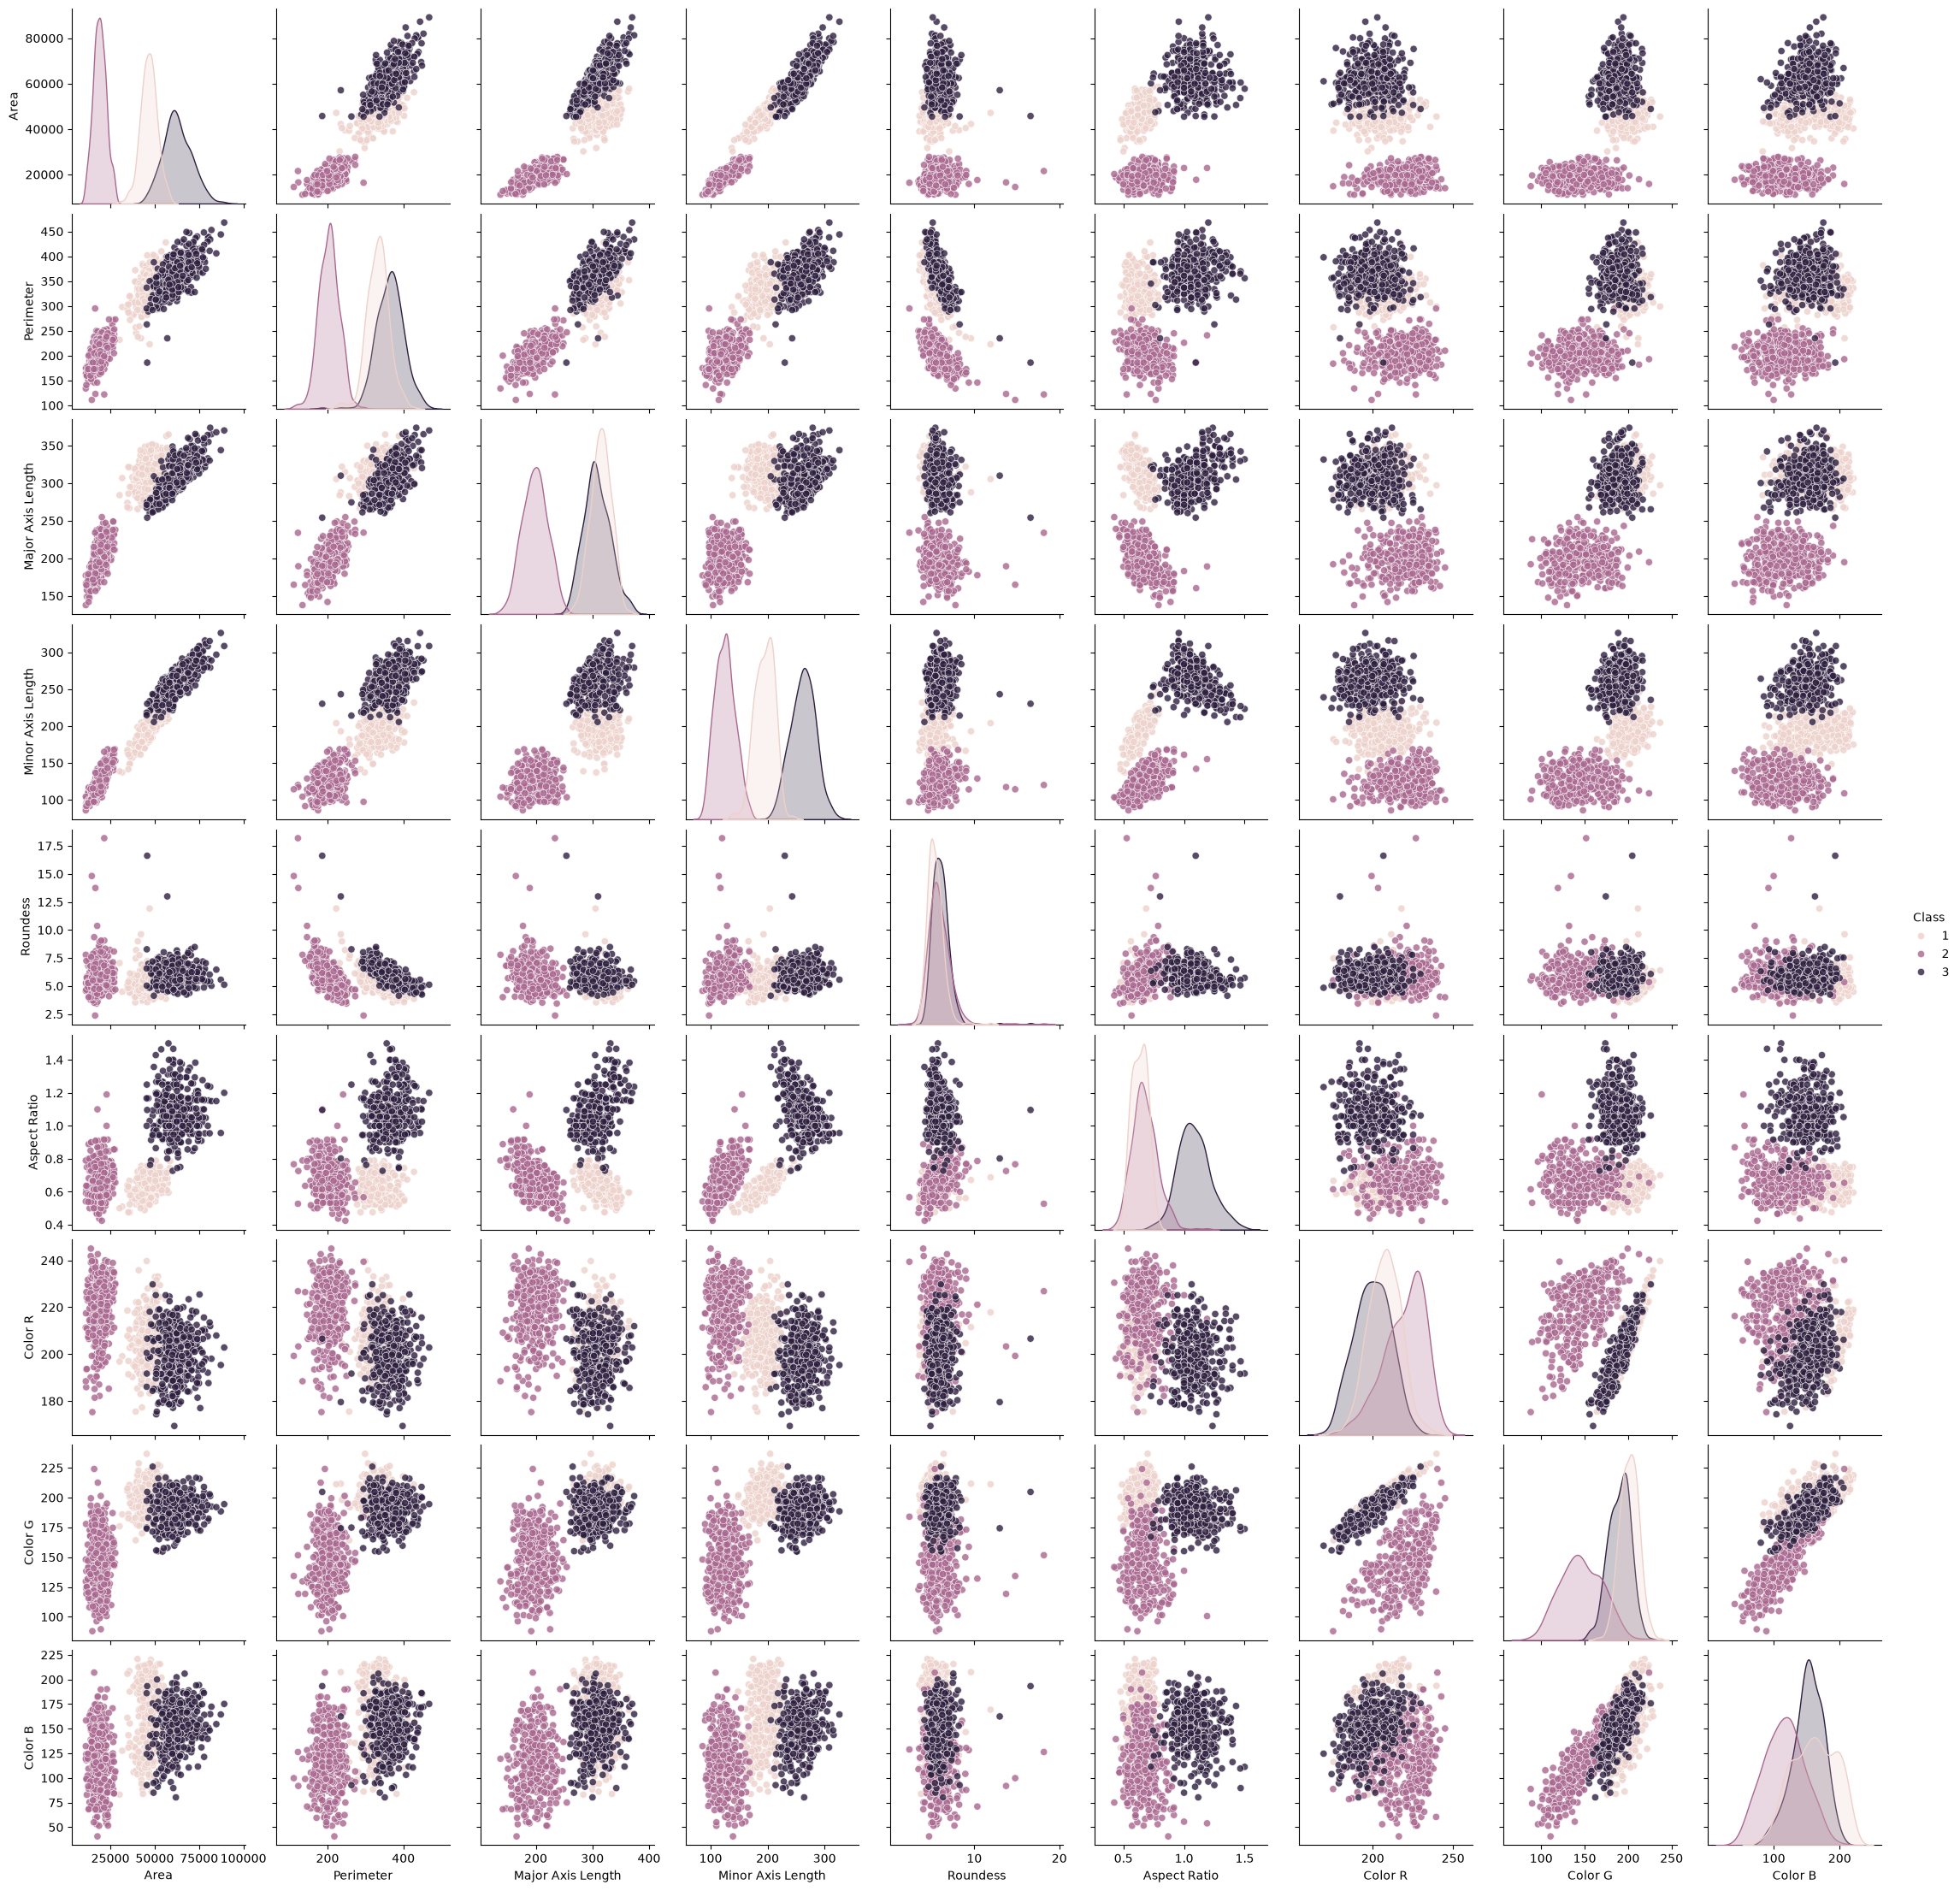

In [26]:
sns.pairplot(df, hue='Class', plot_kws={'alpha': 0.8})
plt.show()

In [27]:
cols = df.select_dtypes(include=['int64', 'float64']).columns

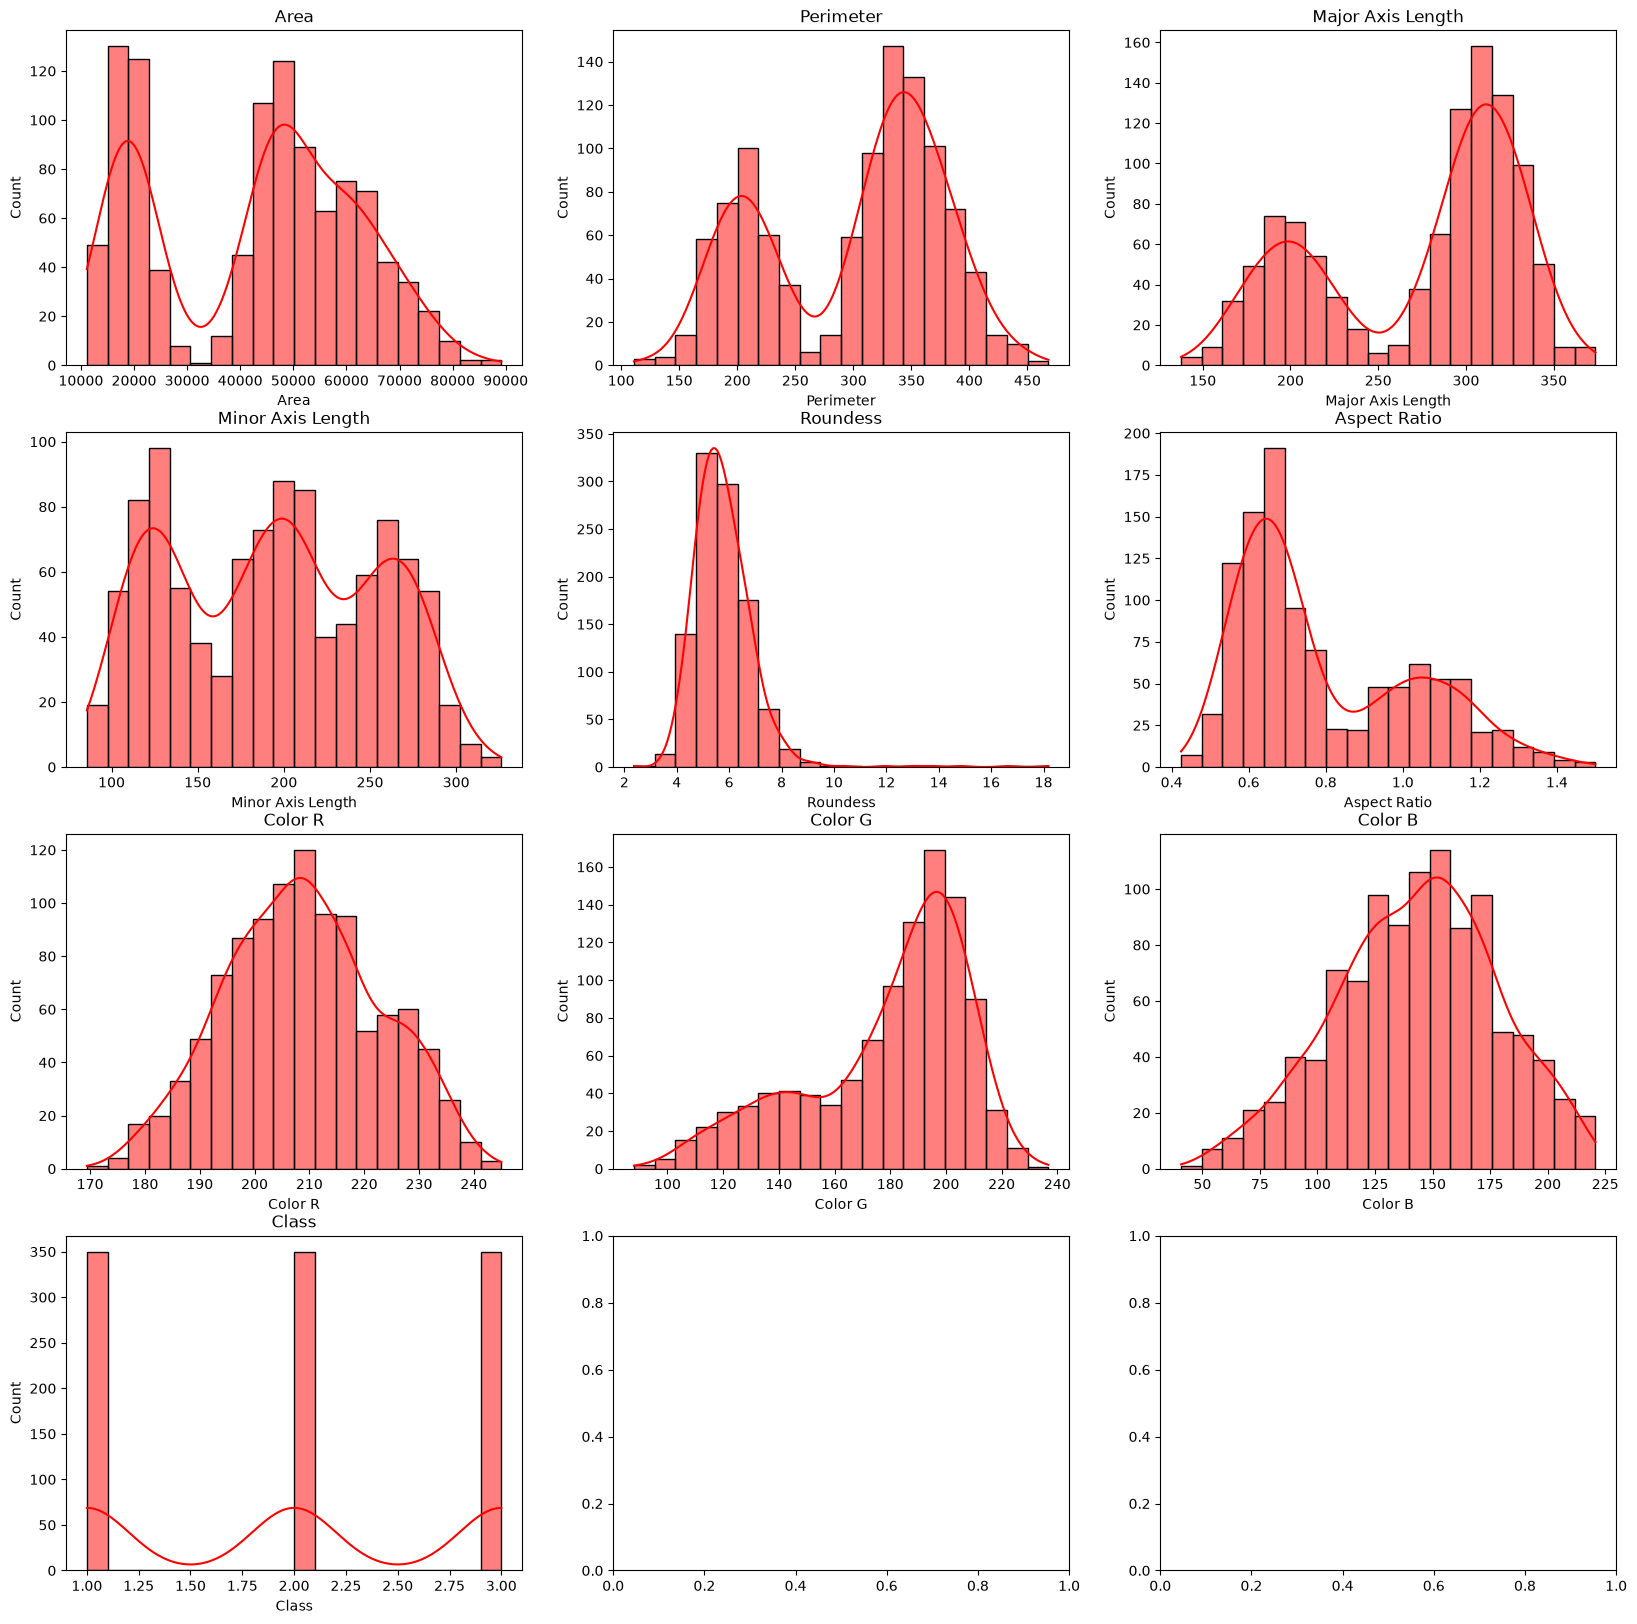

In [30]:
fig, axes = plt.subplots(4, 3, figsize=(20,20))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, color='red', bins=20, ax=axes[i])
    axes[i].set_title(col)

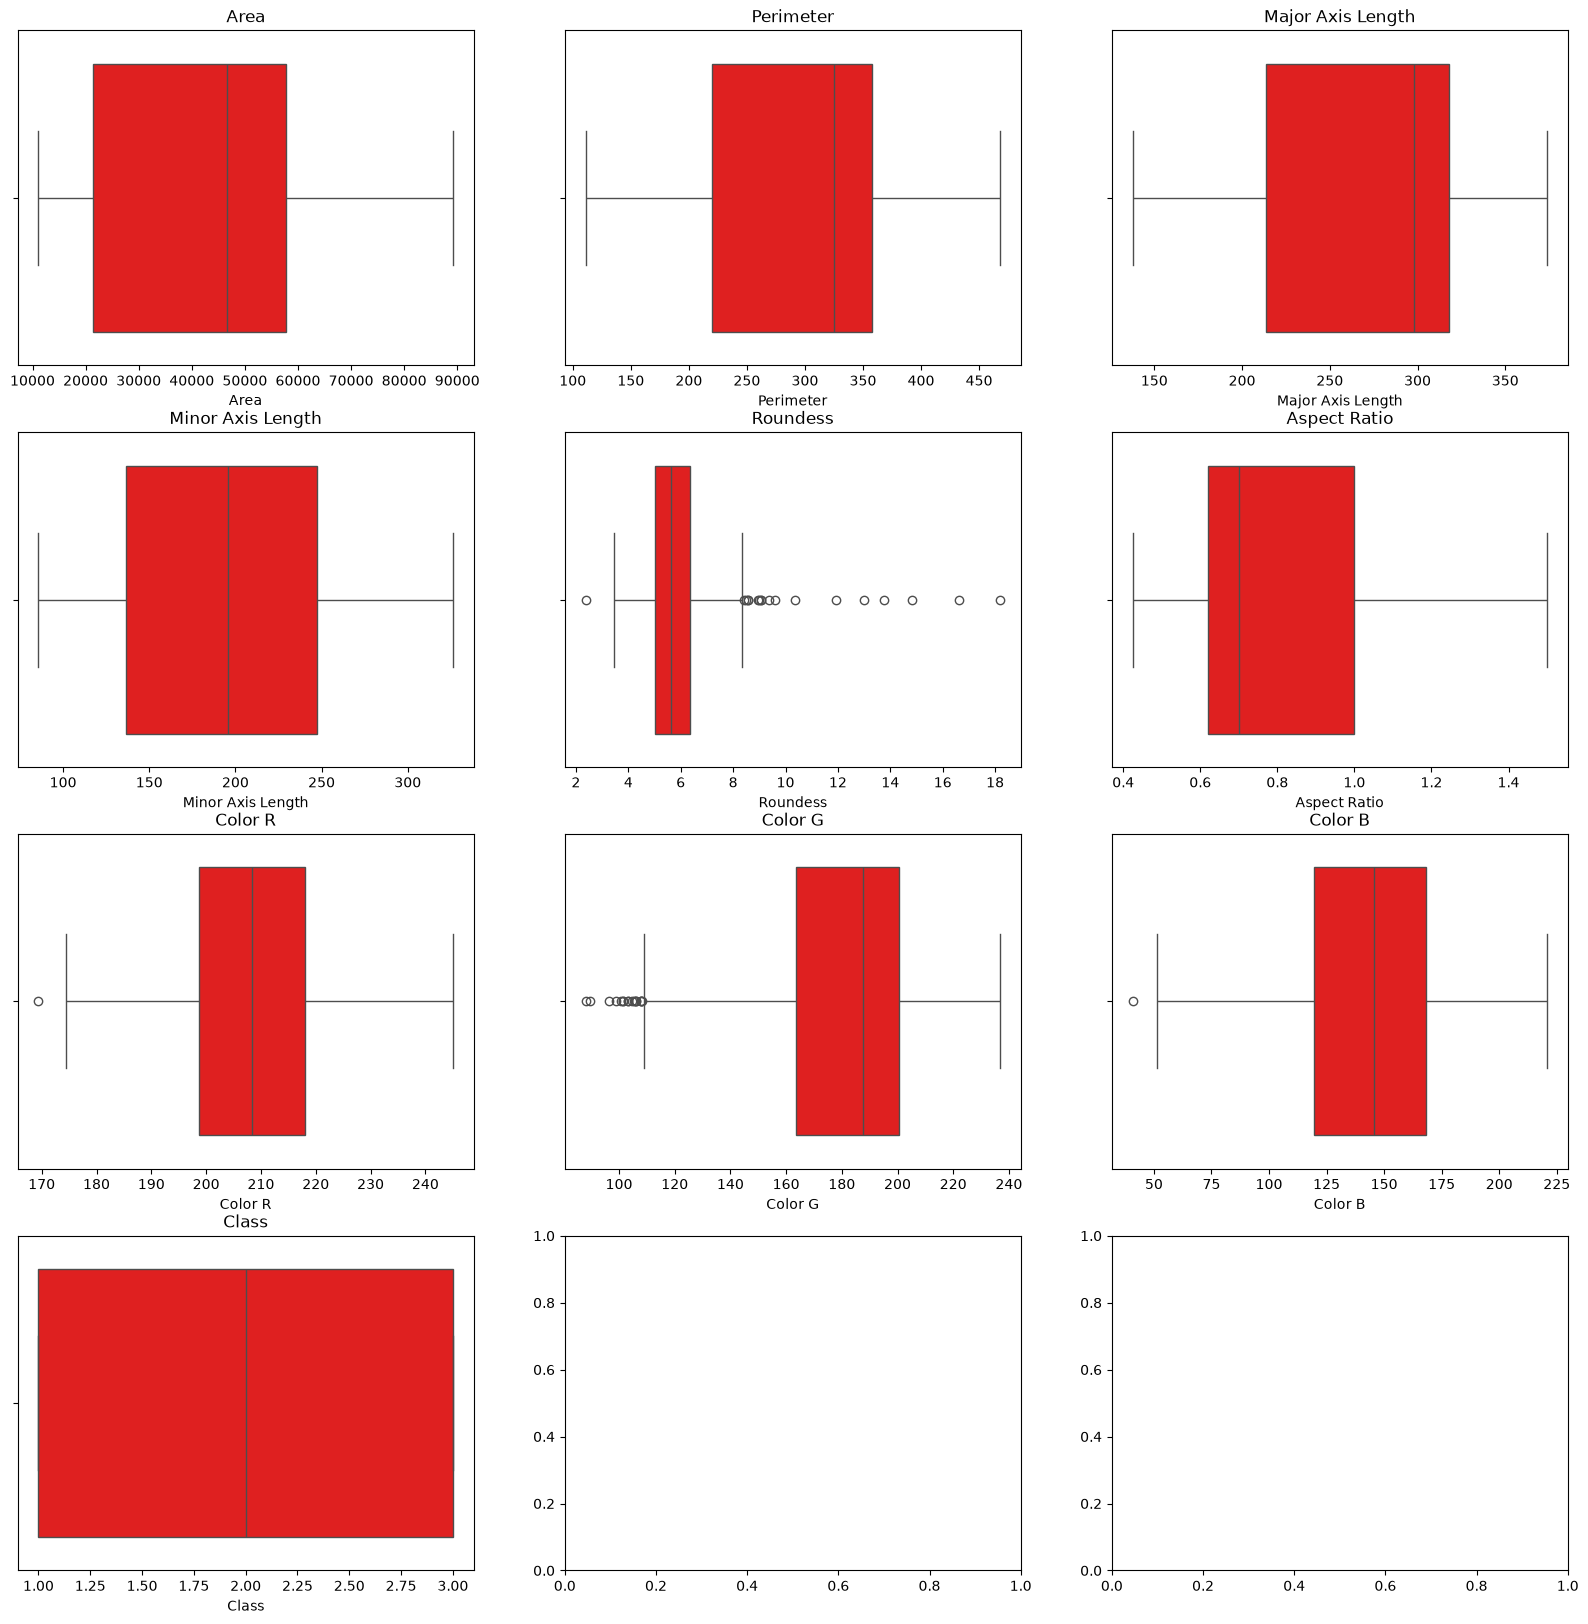

In [33]:
fig, axes = plt.subplots(4, 3, figsize=(20,20))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(x=df[col], color='red', ax=axes[i])
    axes[i].set_title(col)

<Axes: >

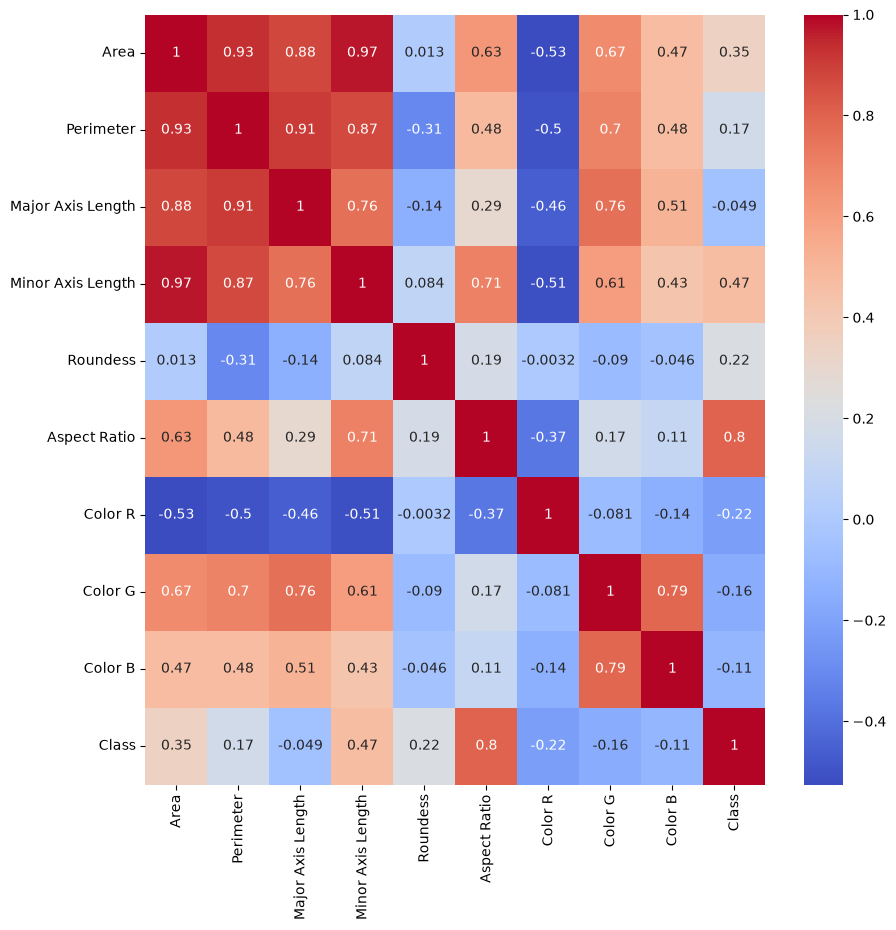

In [36]:
corr_matrix = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm')

### Slip Data

In [63]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((840, 9), (210, 9), (840,), (210,))

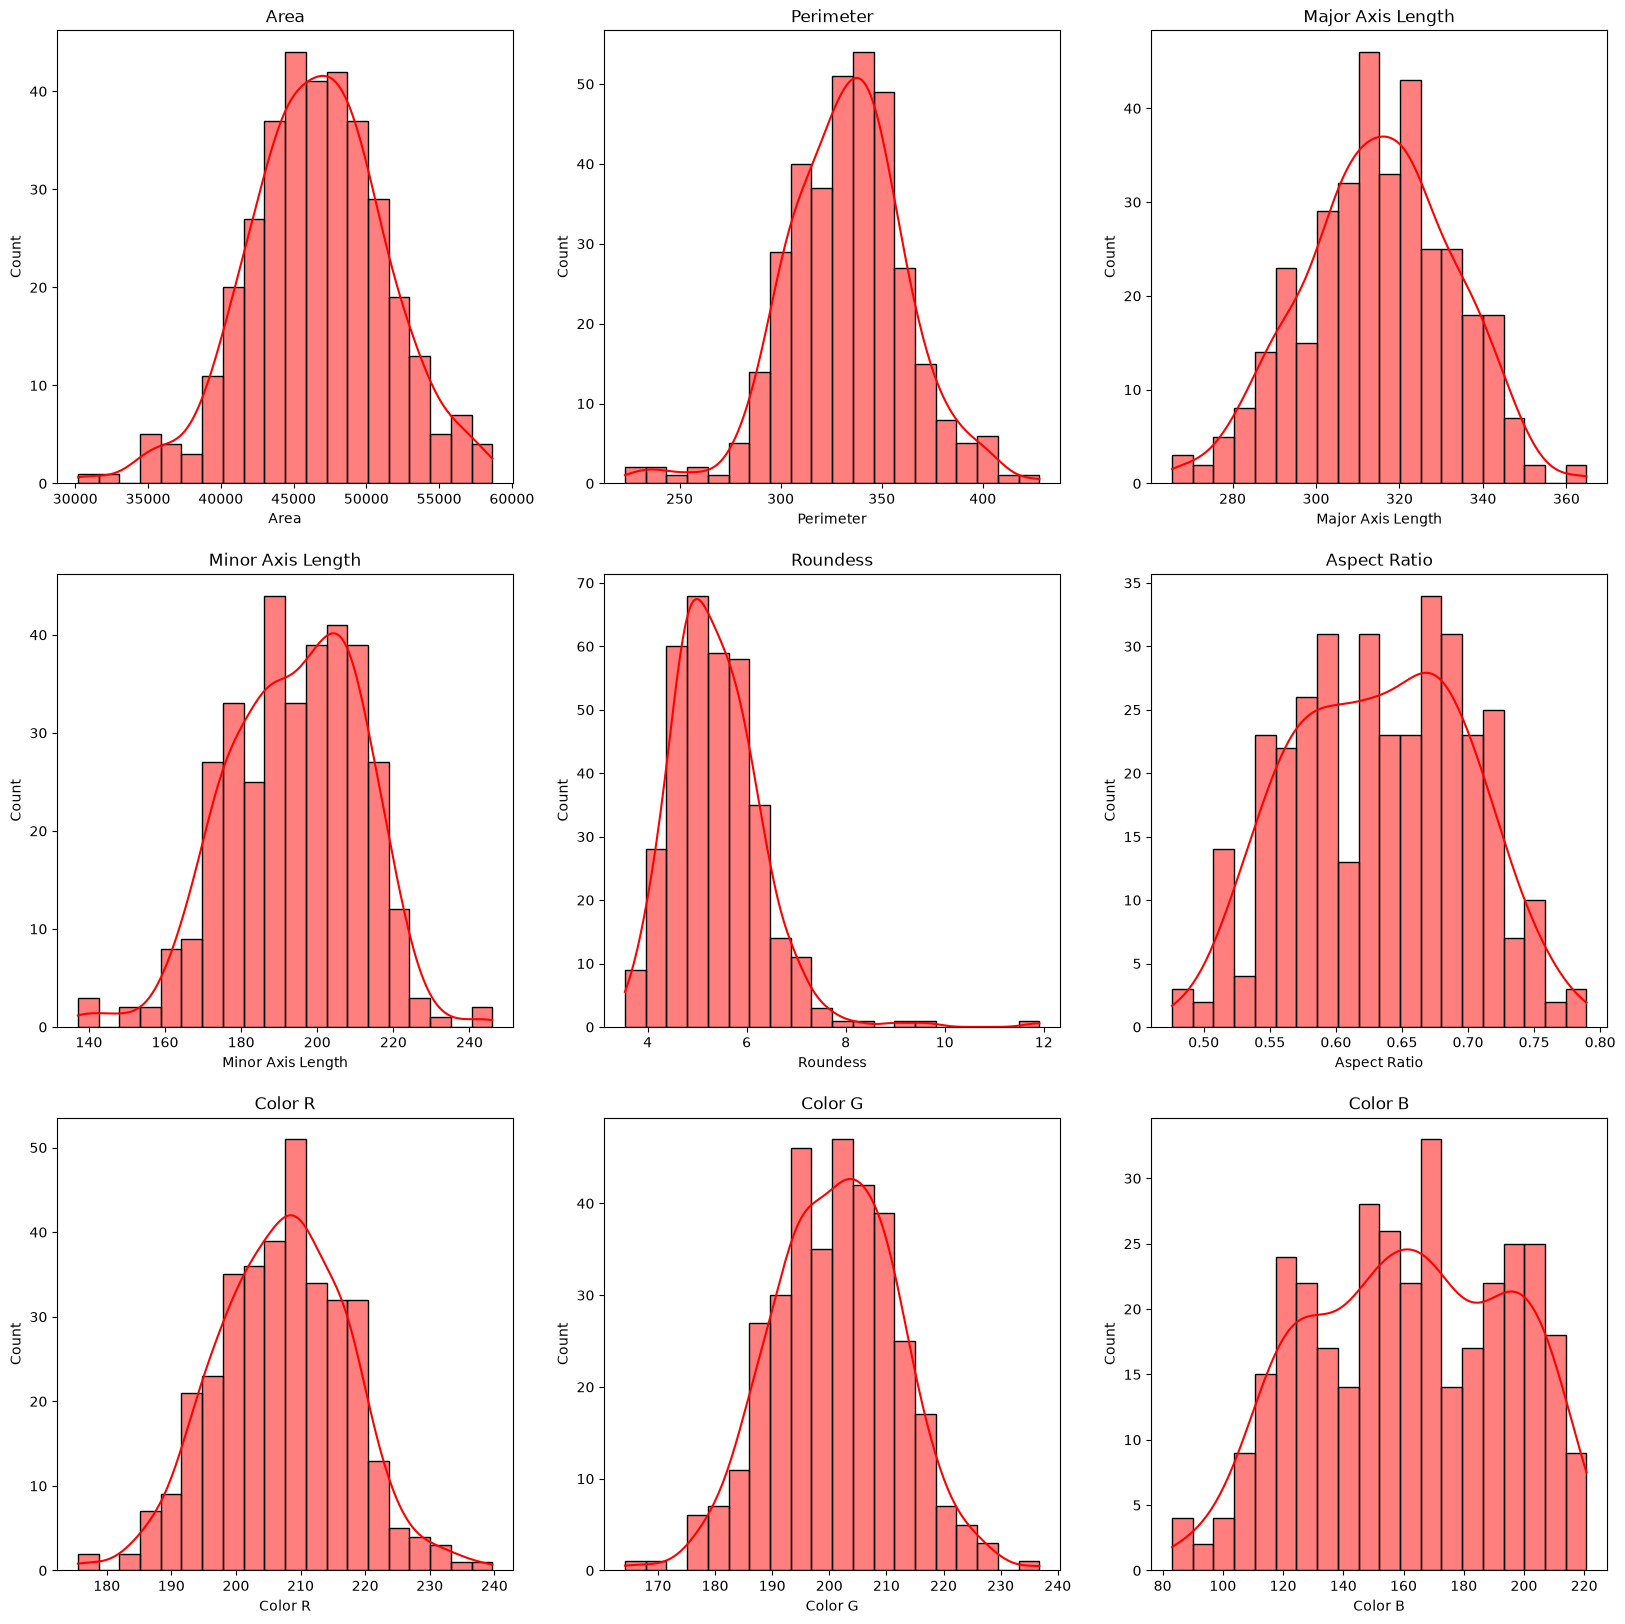

In [ ]:
# Visuale Chulpi Cancha

# ==============================================================================
# GAUSSIAN NAIVE BAYES FEASIBILITY ASSESSMENT (CLASS 1: CHULPI CANCHA)
# ==============================================================================
# 1. OVERALL EVALUATION:
#    - Gaussian Naive Bayes (GNB) is a HIGHLY IDEAL and robust model for this label.
#    - Isolating Class 1 completely resolves the multimodal (multi-peak) anomalies 
#      observed in the master dataset, restoring a clean unimodal structure.

# 2. GREEN FLAGS (Strict Gaussian Adherence):
#    - Geometric Metrics ('Area', 'Perimeter', 'Major Axis Length', 'Minor Axis Length'):
#      Show near-perfect symmetrical bell curves centered around the mean.
#    - Color Profiles ('Color R', 'Color G'):
#      Exhibit highly concentrated normal distributions, proving pigmentation consistency.
#    - GNB will learn these 6 features with extreme statistical accuracy using (mu, sigma^2).

# 3. RED FLAGS & DIVERGENCES (Violations of Normality):
#    - 'Roundness' is heavily RIGHT-SKEWED (Log-Normal appearance):
#      Most kernels group tightly at lower values due to their natural elongated shape, 
#      leaving a long tail of sparse outliers extending towards the right.
#    - 'Color B' exhibits a FLAT/UNIFORM distribution:
#      Lacks a definitive central peak, indicating high variance or low discriminative power.
# ==============================================================================


chulpi_cancha_df = X.iloc[:350, :]
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
axes = axes.flatten()
cols = X.select_dtypes(include=['int64', 'float64']).columns
for i, col in enumerate(cols):
    sns.histplot(data=chulpi_cancha_df[col], kde=True, bins=20, color='red', ax=axes[i])
    axes[i].set_title(col)

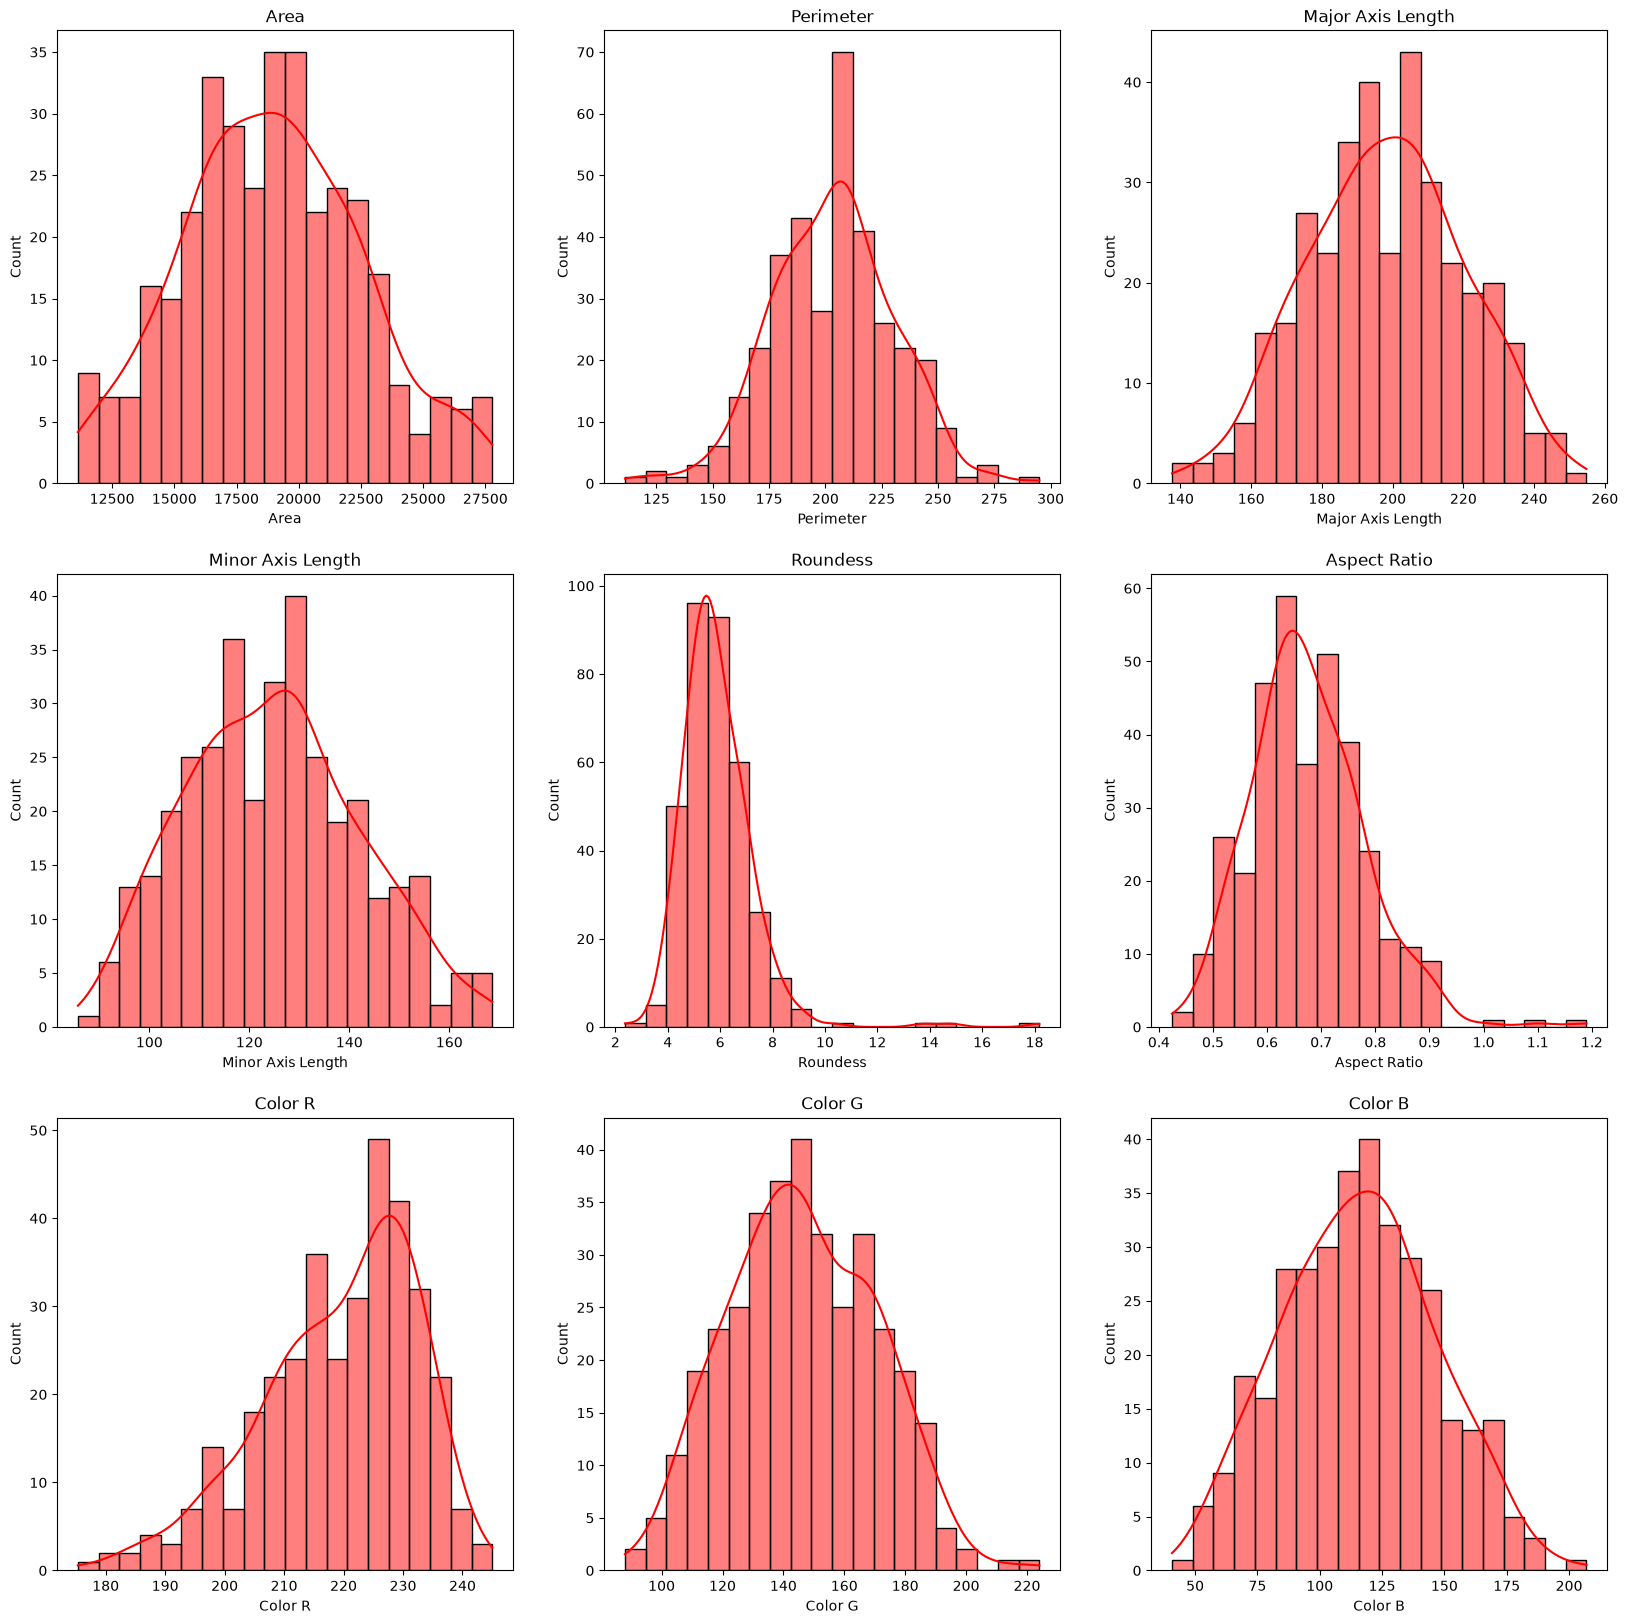

In [ ]:
# ==============================================================================
# GAUSSIAN NAIVE BAYES FEASIBILITY ASSESSMENT (CLASS 2: INDURATA)
# ==============================================================================
# 1. OVERALL EVALUATION:
#    - Gaussian Naive Bayes is EXTREMELY SUITED and highly recommended for Class 2.
#    - The statistical adherence to normality in this subset is even stronger than 
#      in Class 1, especially within the color pigmentation feature space.

# 2. GREEN FLAGS (Excellent Gaussian Alignment):
#    - Color Profiles ('Color R', 'Color G', 'Color B'):
#      Unlike Class 1, all three color channels here exhibit beautiful, symmetrical 
#      bell curves with distinct central peaks. This guarantees powerful variance-based 
#      discriminative capabilities for variety identification.
#    - Structural Lengths ('Major Axis Length', 'Minor Axis Length', 'Aspect Ratio'):
#      Show highly stable, well-behaved unimodal distributions centered clean on the mean.

# 3. RED FLAGS & OBSERVATIONS (Minor Deviations):
#    - 'Roundness' remains RIGHT-SKEWED:
#      Similar to Class 1, the geometric circularity maps a long right-extending tail 
#      (outliers up to 18), indicating a small fraction of highly asymmetrical seeds.
#    - 'Area' and 'Perimeter':
#      Display slight plateauing at the peak (Platykurtic tendency) but safely preserve 
#      the foundational unimodal structure required by the Gaussian PDF.

# 4. IMPLEMENTATION VERDICT:
#    - No structural changes to the pipeline are necessary for this class. 
#    - The synchronized bell curves across 8 out of 9 features will provide 
#      highly stable likelihood estimation during model training.
# ==============================================================================

indurata_df = X.iloc[350:350 + 350, :]
fig, axes = plt.subplots(3, 3, figsize=(20,20))
axes = axes.flatten()
cols = indurata_df.select_dtypes(include=['int64', 'float64']).columns
for i, col in enumerate(cols):
    sns.histplot(data=indurata_df[col], kde=True, bins=20, color='red', ax=axes[i])
    axes[i].set_title(col)

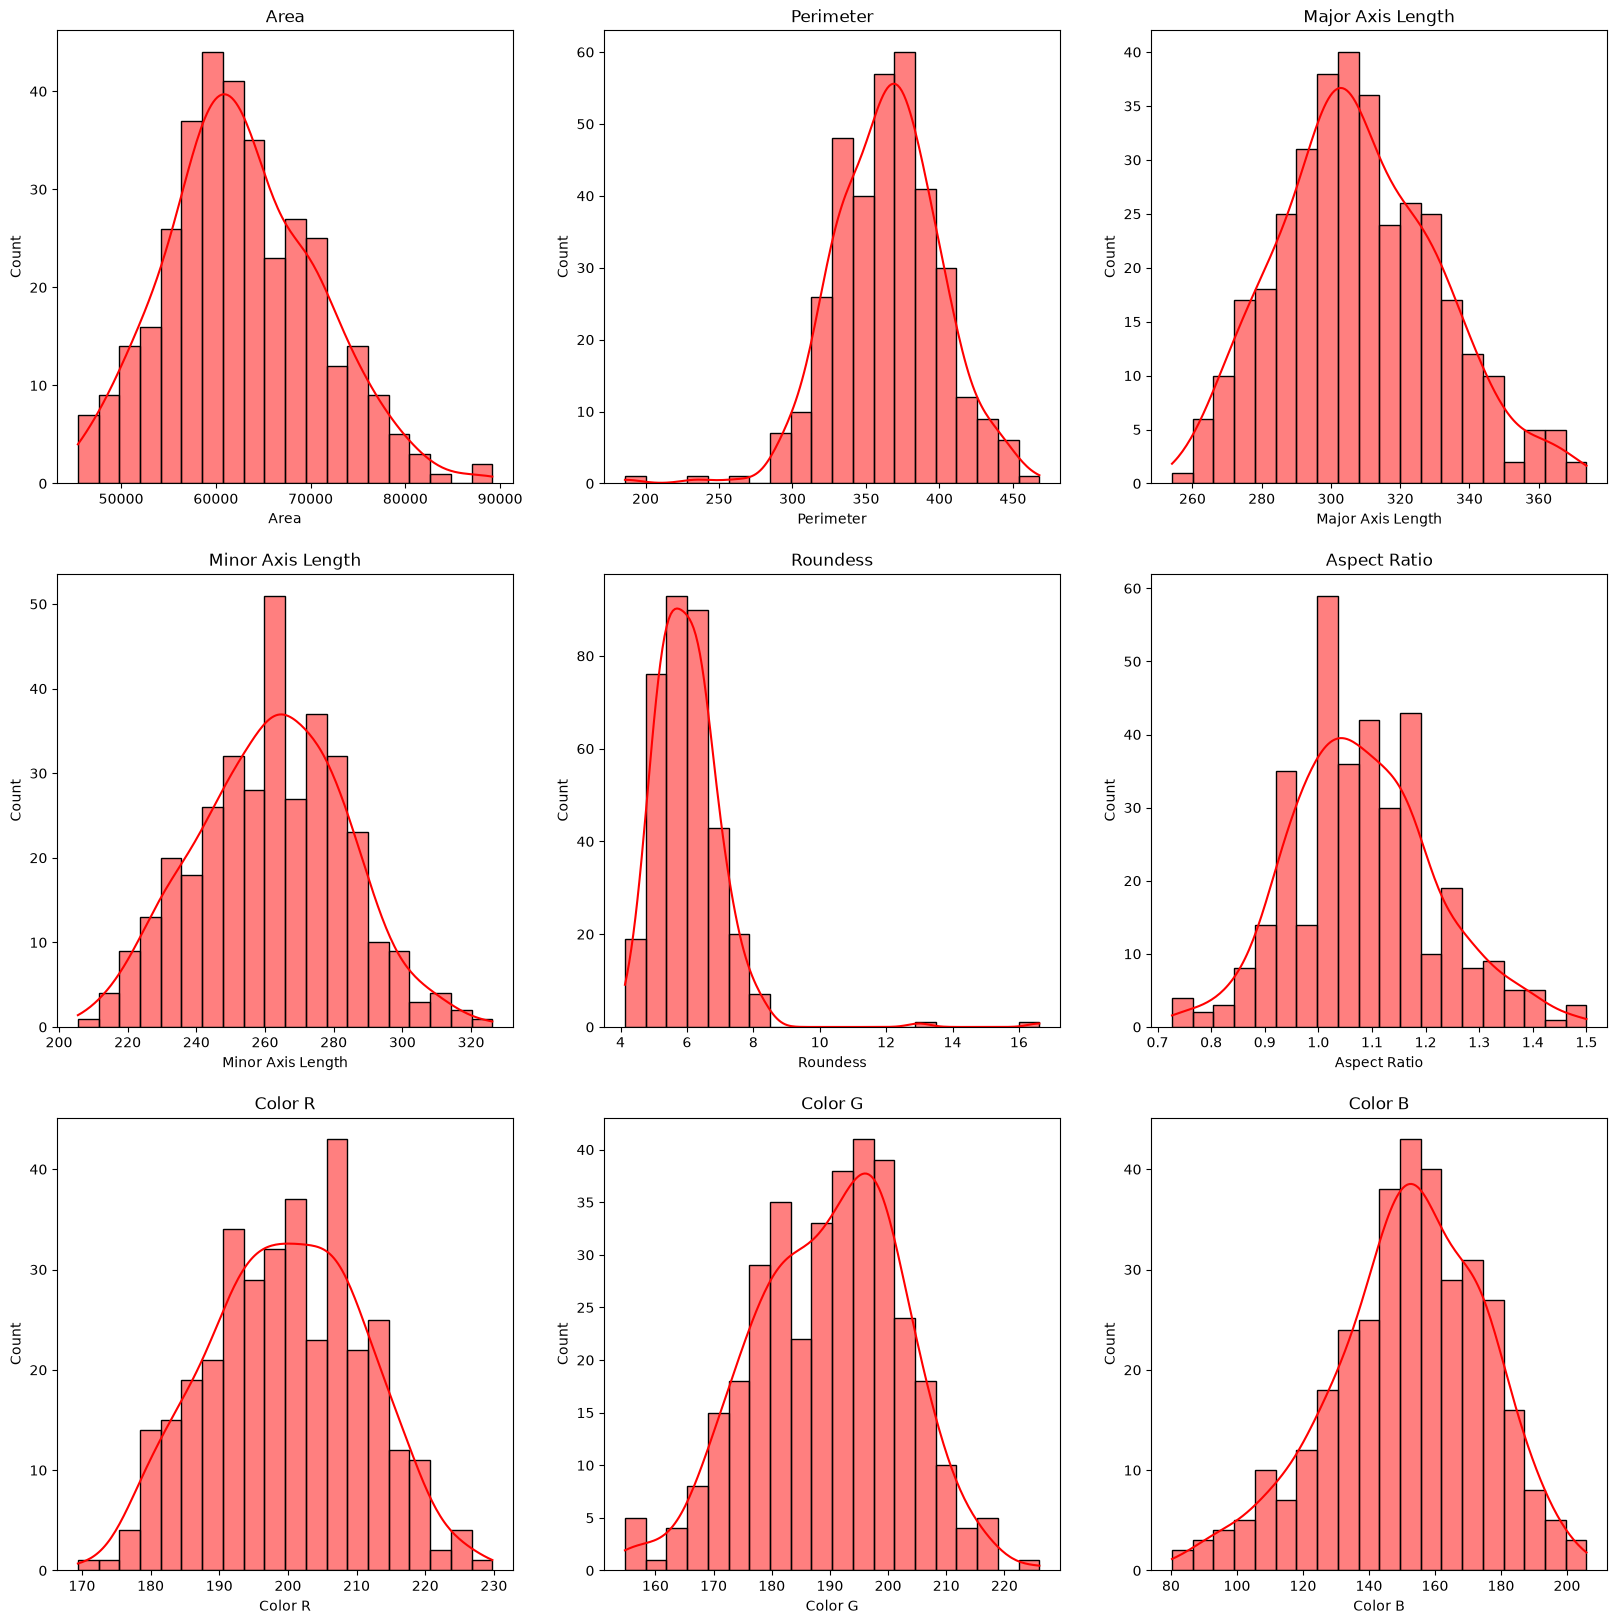

In [ ]:
# ==============================================================================
# GAUSSIAN NAIVE BAYES FEASIBILITY ASSESSMENT (CLASS 3: RUGOSA)
# ==============================================================================
# 1. OVERALL EVALUATION:
#    - Gaussian Naive Bayes is HIGHLY COMPATIBLE and ideal for Class 3.
#    - The statistical metrics of the Rugosa variety tightly mirror foundational 
#      normality assumptions across almost all morphological and color channels.

# 2. GREEN FLAGS (Strong Unimodal & Symmetrical Alignment):
#    - Physical Dimensions ('Area', 'Perimeter', 'Major_L', 'Minor_L'):
#      Exhibit highly defined, sharp bell curves with perfectly centered peaks. 
#      The clean symmetry indicates structural homogeneity within the Rugosa samples.
#    - Color Profiles ('Color R', 'Color G', 'Color B'):
#      Maintain robust, well-behaved Gaussian bell shapes. This clean distribution 
#      ensures reliable class-conditional likelihood estimation ($P(x_i | Y=3)$).
#    - 'Aspect Ratio':
#      Concentrates heavily around 1.0 to 1.2, mathematically confirming the distinct, 
#      flat/squarish physical shape of the sweet corn kernels.

# 3. RED FLAGS & MINOR OBSERVATIONS:
#    - 'Roundness' remains skewed but highly stable:
#      While it retains a slight right-sided tail, the distribution is much tighter 
#      and cleaner than Class 1 and Class 2, capped naturally without extreme outliers.

# 4. FINAL PIPELINE VERDICT (COMPLETED DATASET DOSSIER):
#    - Across all 3 classes (Chulpi, Indurata, Rugosa), isolating the subsets has 
#      successfully decomposed the messy multimodal data into clean Gaussian curves.
#    - The continuous feature space is now mathematically primed and 100% ready 
#      for the manual or library-based Gaussian Naive Bayes classification loop.
# ==============================================================================

rugosa_df = X.iloc[700:1050, :]
fig, axes = plt.subplots(3, 3, figsize=(20,20))
axes = axes.flatten()
cols = X.select_dtypes(include=['int64', 'float64']).columns
for i, col in enumerate(cols):
    sns.histplot(data=rugosa_df[col], bins=20, color='red', ax=axes[i], kde=True)
    axes[i].set_title(col)

### Train Data

In [80]:
def compute_gaussian(x, mean, var):
    exponent = math.exp(-((x - mean) ** 2) / (2 * var))
    coefficient = 1.0 / math.sqrt(2 * math.pi * var)
    return coefficient * exponent

In [116]:
model_stats = {}
total_train_samples = len(X_train)
features = ['Area', 'Perimeter', 'Major Axis Length', 'Minor Axis Length', 
            'Roundess', 'Aspect Ratio', 'Color R', 'Color G', 'Color B']

for c in [1, 2, 3]:

    df_c = y_train[y_train == c]

    # Compute Prior Probability P(Y=c)
    prior_prop = len(df_c) / total_train_samples

    model_stats[c] = {
        'prior': prior_prop,
        'features': {}
    }

    X_train_c = X_train[y_train == c]

    for f in features:
        feature_i = X_train_c[f].values
        mean_val = np.mean(feature_i)
        var_val = np.var(feature_i) + 1e-9 
        model_stats[c]['features'][f] = {
            'mean': mean_val,
            'var': var_val
        }

### Predict Data

In [101]:
import math

In [117]:
y_pred = np.zeros(len(X_test)).astype(np.int64)

In [118]:
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [120]:
for i in range(len(X_test)):

    class_scores = {}

    for c in [1, 2, 3]:
        
        log_score = math.log(model_stats[c]['prior'])

        for f in features:
            prob = compute_gaussian(
                X_test.loc[i, f], 
                model_stats[c]['features'][f]['mean'],
                model_stats[c]['features'][f]['var']
            )

            if prob > 0.0:
                log_score += math.log(prob)
            else:
                log_score += math.log(1e-9)

            class_scores[c] = log_score
            
    y_pred[i] = max(class_scores, key=class_scores.get)


### Performance Measure

In [113]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [121]:
print("Classication Report: \n",classification_report(y_test, y_pred))
acc = accuracy_score(y_test,y_pred)
print("Accuracy Score: ",acc*100,"%")

Classication Report: 
               precision    recall  f1-score   support

           1       0.99      1.00      0.99        70
           2       1.00      1.00      1.00        70
           3       1.00      0.99      0.99        70

    accuracy                           1.00       210
   macro avg       1.00      1.00      1.00       210
weighted avg       1.00      1.00      1.00       210

Accuracy Score:  99.52380952380952 %
